### Imports

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score
)

### Load All Model Data

In [24]:
CHECKPOINT_DIR = "../checkpoints"

MODEL_NAMES = ["efficientnet_b0", "resnet18", "resnet50", "custom_cnn"]
COLORS = ["steelblue", "tomato", "seagreen", "darkorange"]
CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]

all_data = {}
for name in MODEL_NAMES:
    path = f"{CHECKPOINT_DIR}/{name}_outputs/{name}_eval_data.pkl"
    with open(path, "rb") as f:
        all_data[name] = pickle.load(f)
    print(f"Loaded: {name}")

def get(model, key):
    return all_data[model]["best_metrics_f1"][key]

Loaded: efficientnet_b0
Loaded: resnet18
Loaded: resnet50
Loaded: custom_cnn


### Summary Table

In [25]:
rows = {}
for name in MODEL_NAMES:
    rows[name] = {
        "F1 Tuned": get(name, "macro_f1_tuned"),
        "F1 @ 0.5": get(name, "macro_f1@0.5"),
        "ROC-AUC": all_data[name]["macro_auc"],
        "Avg Precision": all_data[name]["macro_ap"],
        "Micro F1": get(name, "micro_f1@0.5"),
        "Exact Match": get(name, "exact_tuned"),
    }

summary_df = pd.DataFrame(rows).T.round(4)
print(summary_df.to_string())

                 F1 Tuned  F1 @ 0.5  ROC-AUC  Avg Precision  Micro F1  Exact Match
efficientnet_b0    0.5264    0.5291   0.8083         0.5411    0.5393       0.2453
resnet18           0.5451    0.5225   0.8184         0.5619    0.5256       0.2037
resnet50           0.5578    0.5437   0.8208         0.5680    0.5501       0.2312
custom_cnn         0.3600    0.3751   0.7177         0.3674    0.3688       0.0286


### Radar Chart

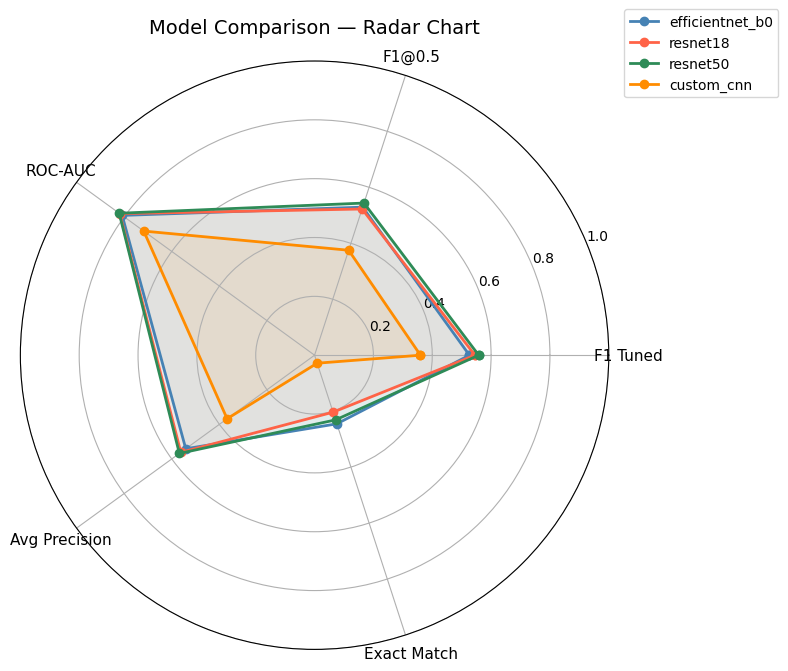

In [26]:
metric_labels = ["F1 Tuned", "F1@0.5", "ROC-AUC", "Avg Precision", "Exact Match"]
N = len(metric_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, color in zip(MODEL_NAMES, COLORS):
    values = [
        get(name, "macro_f1_tuned"),
        get(name, "macro_f1@0.5"),
        all_data[name]["macro_auc"],
        all_data[name]["macro_ap"],
        get(name, "exact_tuned"),
    ]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Radar Chart", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

### Summary Bar Chart (F1, ROC-AUC, Avg Precision)

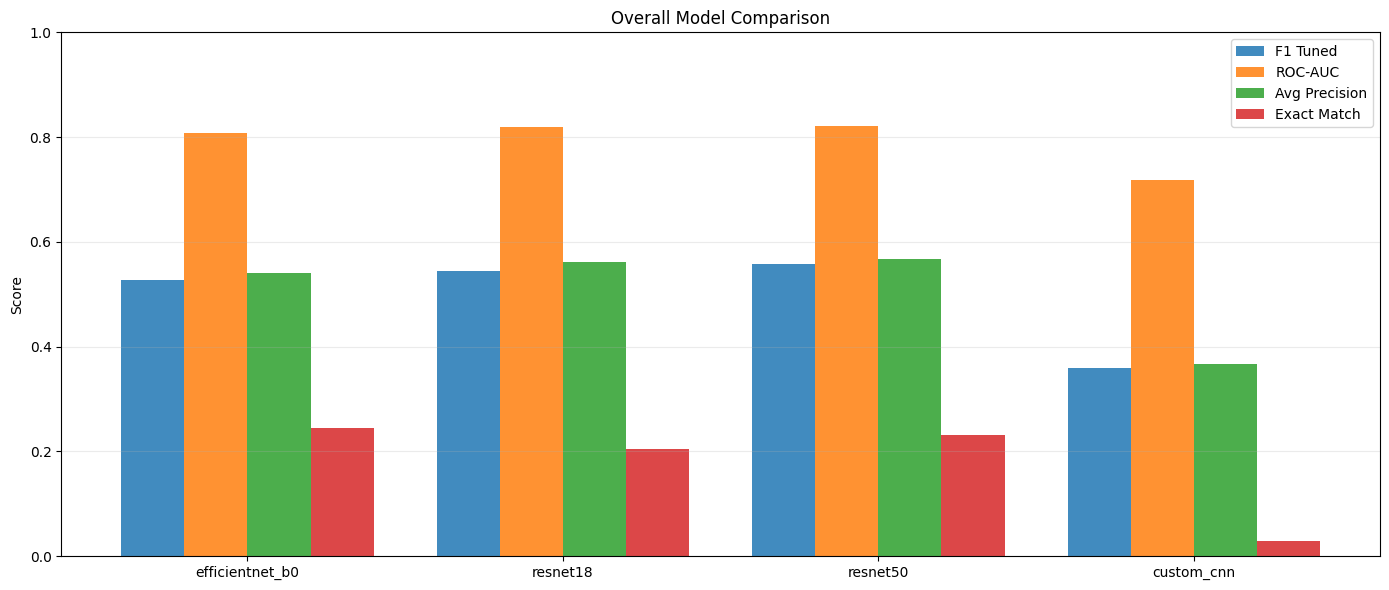

In [27]:
metrics_to_plot = ["F1 Tuned", "ROC-AUC", "Avg Precision", "Exact Match"]
values_map = {
    "F1 Tuned": [get(n, "macro_f1_tuned") for n in MODEL_NAMES],
    "ROC-AUC": [all_data[n]["macro_auc"] for n in MODEL_NAMES],
    "Avg Precision": [all_data[n]["macro_ap"] for n in MODEL_NAMES],
    "Exact Match": [get(n, "exact_tuned") for n in MODEL_NAMES],
}

x = np.arange(len(MODEL_NAMES))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, vals) in enumerate(values_map.items()):
    ax.bar(x + i * width, vals, width, label=metric, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(MODEL_NAMES)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Overall Model Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Metrics Heatmap

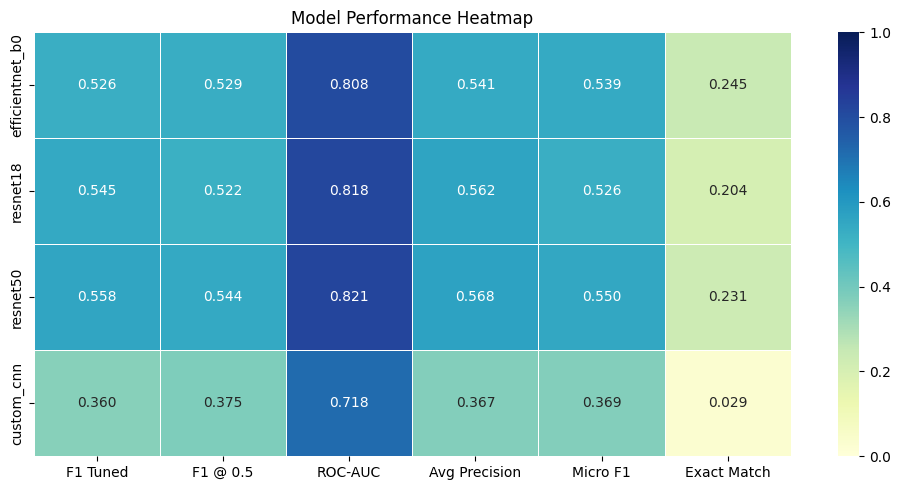

In [28]:
rows = {}
for name in MODEL_NAMES:
    rows[name] = {
        "F1 Tuned": get(name, "macro_f1_tuned"),
        "F1 @ 0.5": get(name, "macro_f1@0.5"),
        "ROC-AUC": all_data[name]["macro_auc"],
        "Avg Precision": all_data[name]["macro_ap"],
        "Micro F1": get(name, "micro_f1@0.5"),
        "Exact Match": get(name, "exact_tuned"),
    }

heatmap_df = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt=".3f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title("Model Performance Heatmap")
plt.tight_layout()
plt.show()

### Combined Training History


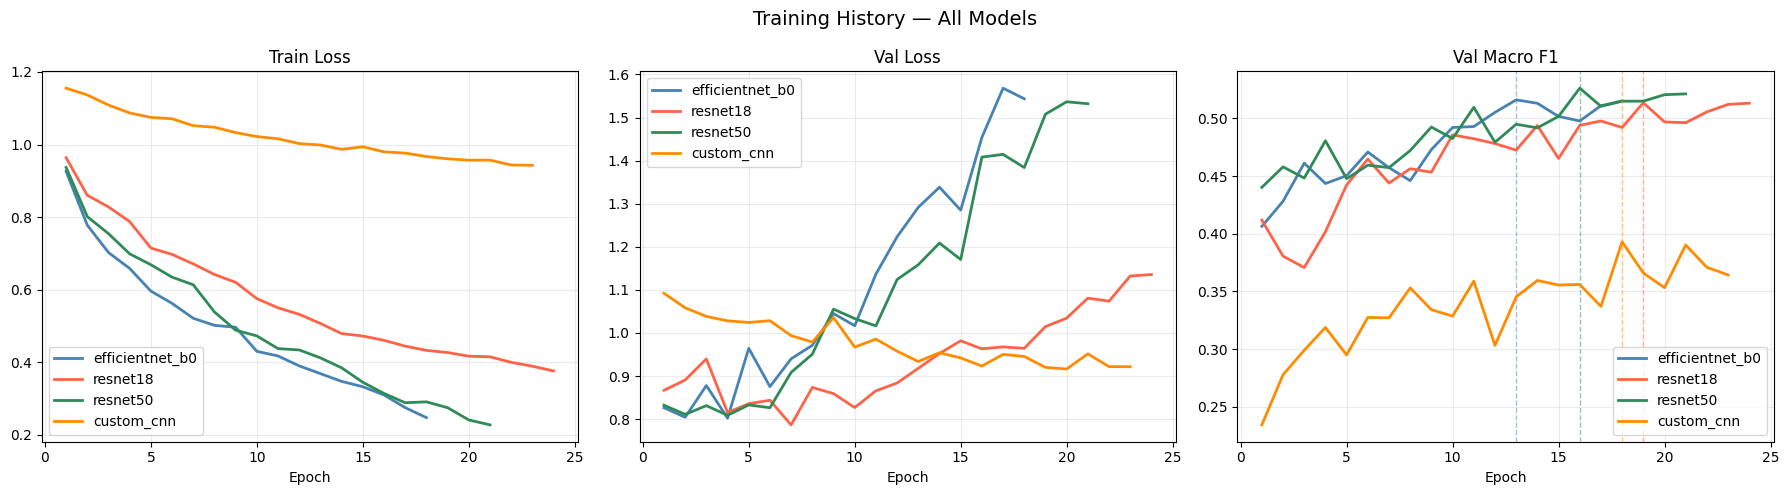

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, color in zip(MODEL_NAMES, COLORS):
    h = pd.DataFrame(all_data[name]["history"])
    axes[0].plot(h["epoch"], h["train_loss"], lw=2, color=color, label=name)
    axes[1].plot(h["epoch"], h["val_loss"], lw=2, color=color, label=name)
    axes[2].plot(h["epoch"], h["val_macro_f1"], lw=2, color=color, label=name)
    best_ep = all_data[name]["best_epoch_f1"]
    axes[2].axvline(best_ep, color=color, linestyle="--", lw=1, alpha=0.5)

axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].set_title("Val Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.25)
axes[2].set_title("Val Macro F1"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.25)

plt.suptitle("Training History — All Models", fontsize=14)
plt.tight_layout()
plt.show()

### Per-class F1 bar chart all models

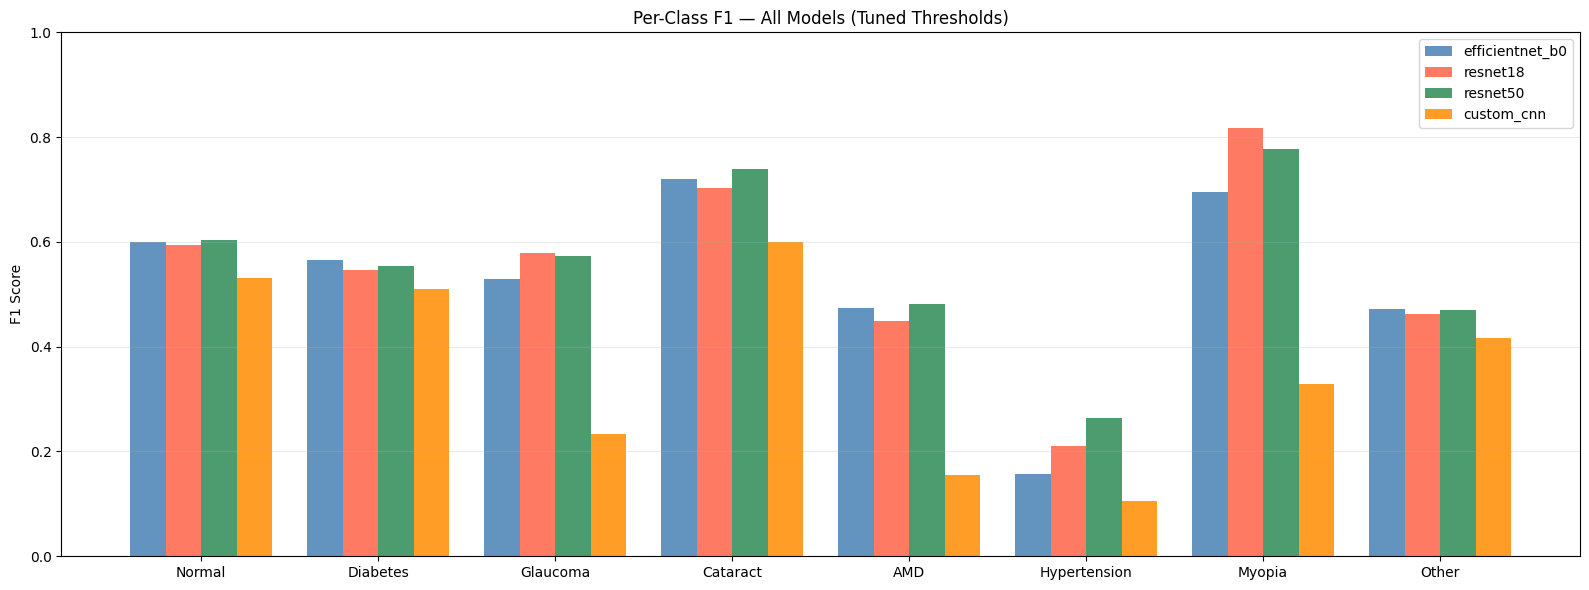

In [30]:
x = np.arange(len(CLASS_NAMES))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
    f1s = get(name, "per_class_f1_tuned")
    ax.bar(x + i * width, f1s, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 — All Models (Tuned Thresholds)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Per-class ROC-AUC heatmap

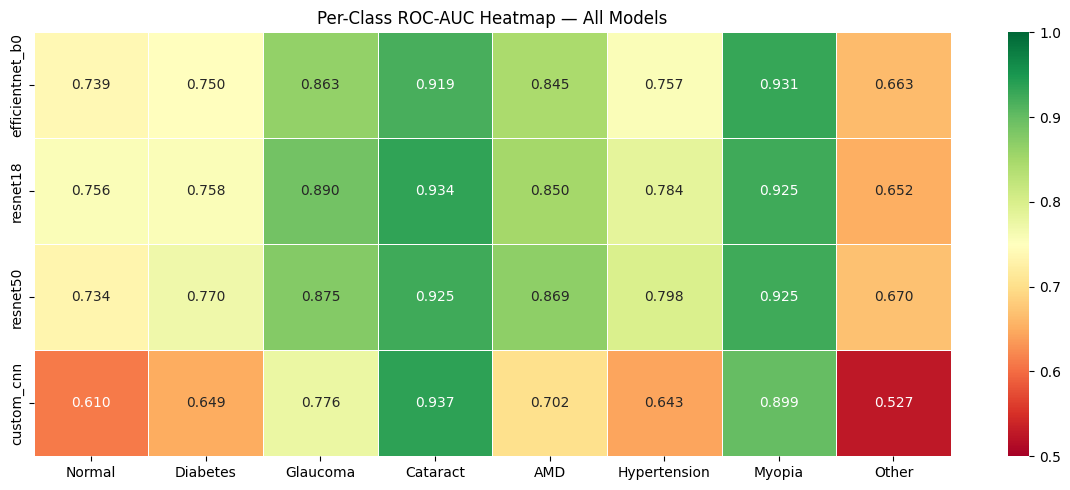

In [31]:
auc_matrix = {}
for name in MODEL_NAMES:
    aucs = []
    for i in range(8):
        t = all_data[name]["targets"][:, i]
        p = all_data[name]["probs"][:, i]
        aucs.append(roc_auc_score(t, p) if len(np.unique(t)) >= 2 else np.nan)
    auc_matrix[name] = aucs

auc_df = pd.DataFrame(auc_matrix, index=CLASS_NAMES).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    auc_df, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0.5, vmax=1.0,
    ax=ax, linewidths=0.5
)
ax.set_title("Per-Class ROC-AUC Heatmap — All Models")
plt.tight_layout()
plt.show()

### ROC curves per class all models

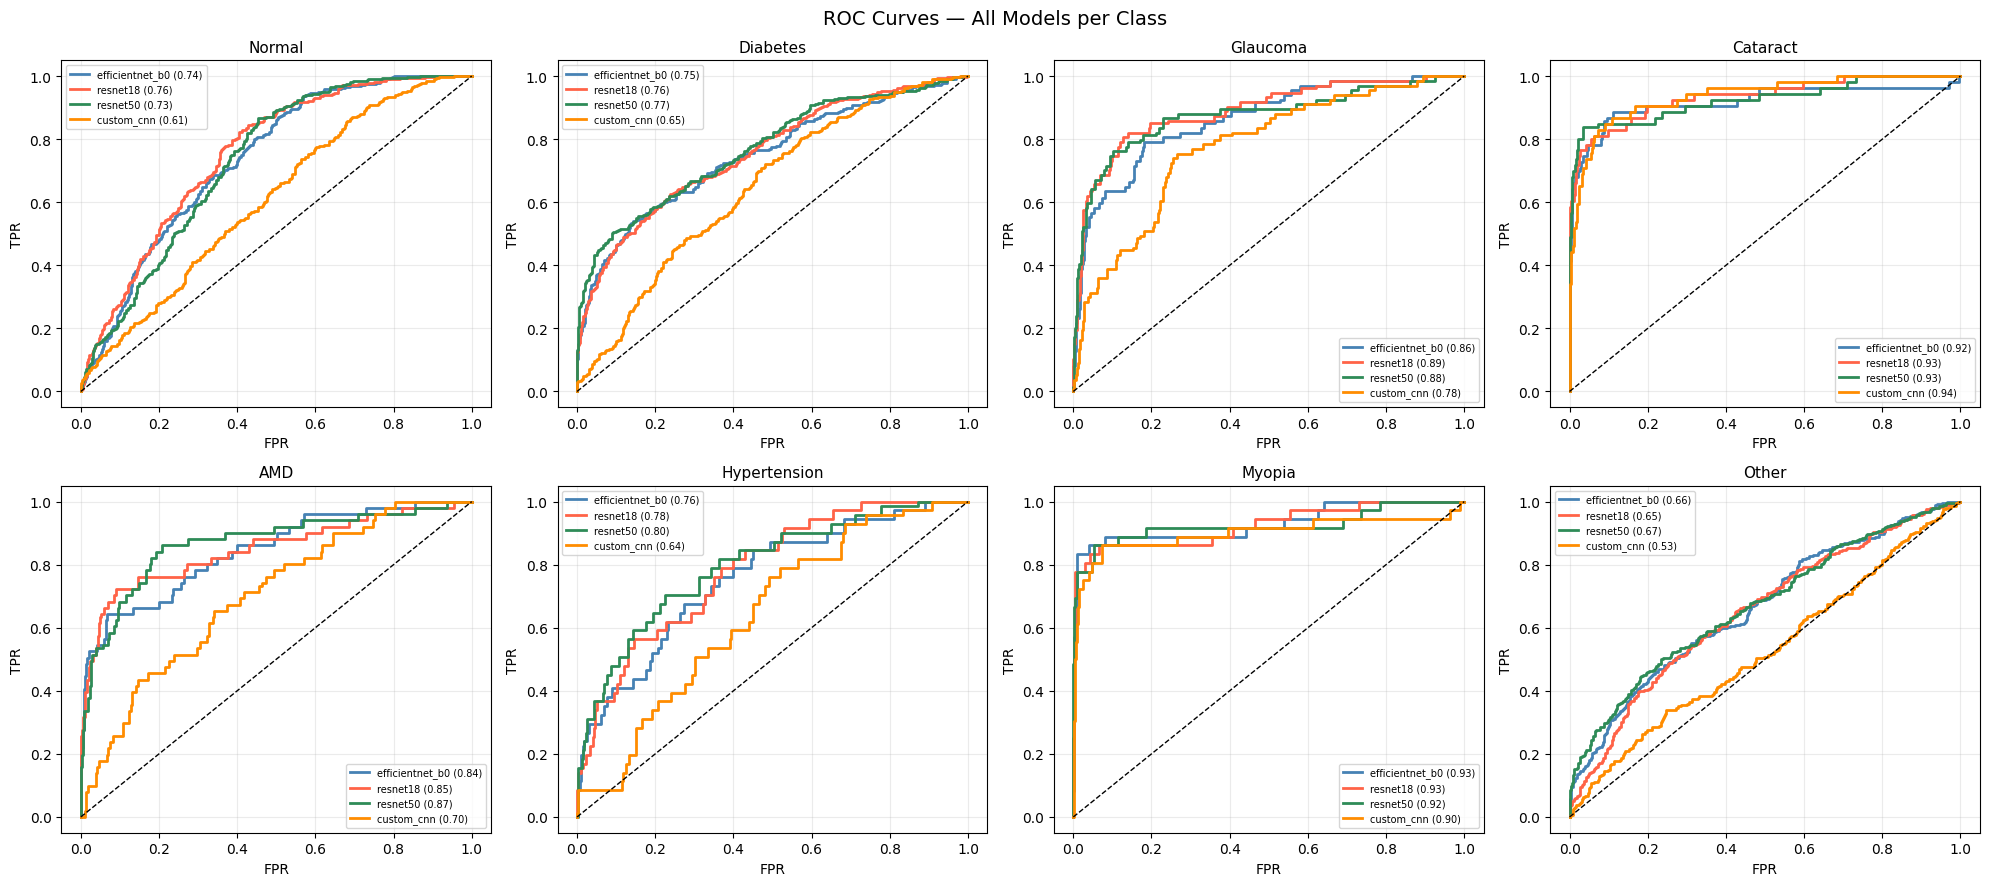

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for class_idx, class_name in enumerate(CLASS_NAMES):
    ax = axes[class_idx]
    for name, color in zip(MODEL_NAMES, COLORS):
        t = all_data[name]["targets"][:, class_idx]
        p = all_data[name]["probs"][:, class_idx]
        if len(np.unique(t)) < 2:
            continue
        auc = roc_auc_score(t, p)
        fpr, tpr, _ = roc_curve(t, p)
        ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} ({auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(class_name, fontsize=11)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle("ROC Curves — All Models per Class", fontsize=14)
plt.tight_layout()
plt.show()

### Threshold sensitivity analysis

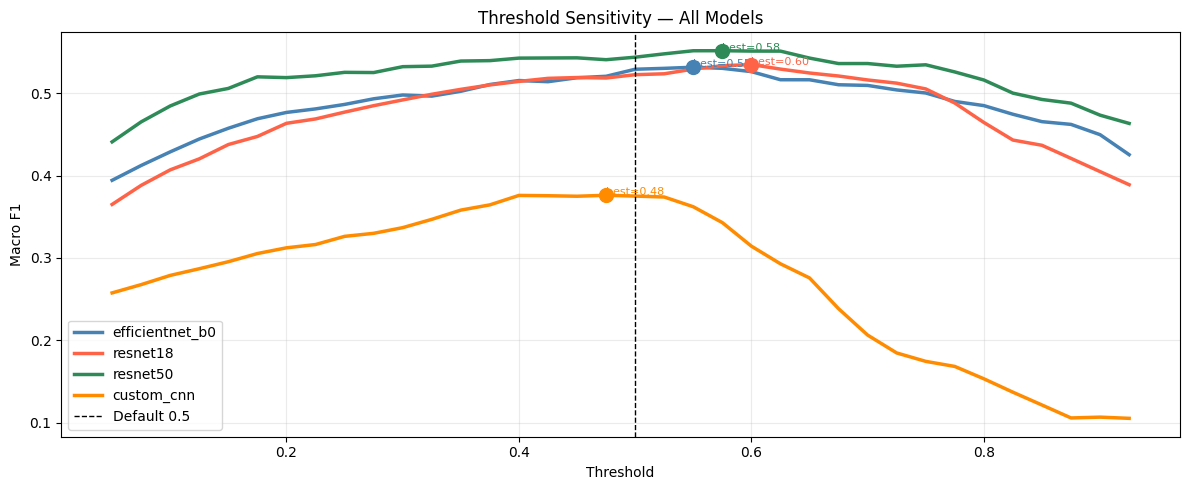

In [33]:
thresholds = np.arange(0.05, 0.95, 0.025)

fig, ax = plt.subplots(figsize=(12, 5))

for name, color in zip(MODEL_NAMES, COLORS):
    probs = all_data[name]["probs"]
    targets = all_data[name]["targets"]
    f1s = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1s.append(f1_score(targets, preds, average="macro", zero_division=0))
    ax.plot(thresholds, f1s, lw=2.5, color=color, label=name)
    best_t = thresholds[np.argmax(f1s)]
    ax.scatter([best_t], [max(f1s)], color=color, s=100, zorder=5)
    ax.annotate(f"best={best_t:.2f}", (best_t, max(f1s)), fontsize=8, color=color)

ax.axvline(0.5, color="k", linestyle="--", lw=1, label="Default 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("Macro F1")
ax.set_title("Threshold Sensitivity — All Models")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Final Summary

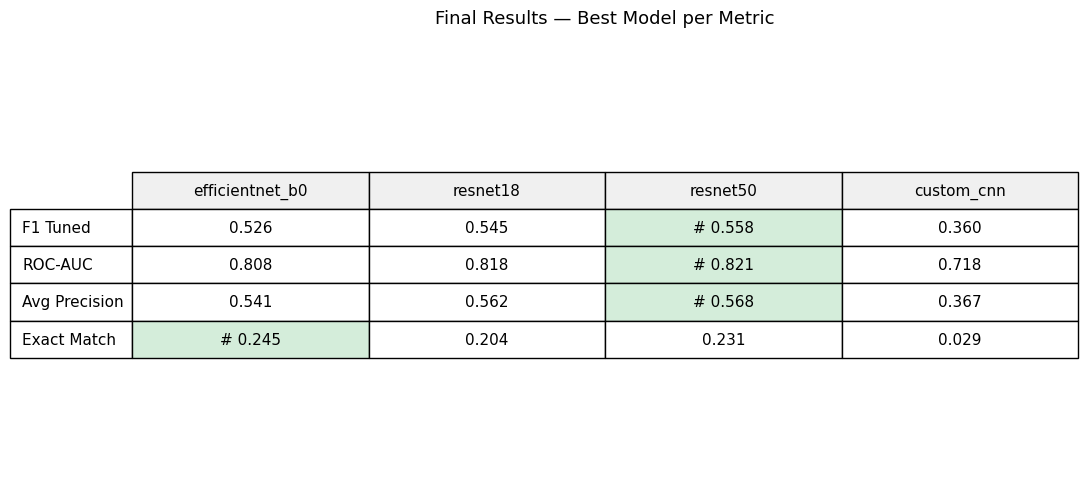

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

metrics = ["F1 Tuned", "ROC-AUC", "Avg Precision", "Exact Match"]
vals = {
    "F1 Tuned": [get(n, "macro_f1_tuned") for n in MODEL_NAMES],
    "ROC-AUC": [all_data[n]["macro_auc"] for n in MODEL_NAMES],
    "Avg Precision": [all_data[n]["macro_ap"] for n in MODEL_NAMES],
    "Exact Match": [get(n, "exact_tuned") for n in MODEL_NAMES],
}

rows = []
for m in metrics:
    row = [f"{v:.3f}" for v in vals[m]]
    best = np.argmax(vals[m])
    row[best] = f"# {row[best]}"
    rows.append(row)

table = ax.table(
    cellText=rows,
    rowLabels=metrics,
    colLabels=MODEL_NAMES,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2)

for (row, col), cell in table.get_celld().items():
    if "#" in str(cell.get_text().get_text()):
        cell.set_facecolor("#d4edda")
    elif row == 0:
        cell.set_facecolor("#f0f0f0")

ax.set_title("Final Results — Best Model per Metric", fontsize=13, pad=20)
plt.tight_layout()
plt.show()